<a href="https://colab.research.google.com/github/franz-ops/IoT-Traffic-Analyzer/blob/main/IoT_23_con_res.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Download Dataset**

Opzioni:

1) Downlaod del dataset e estrazione

2) Importazione del dataset da Drive e estrazione

1) Download del dataset e estrazione

In [ ]:
!wget https://mcfp.felk.cvut.cz/publicDatasets/IoT-23-Dataset/iot_23_datasets_small.tar.gz

--2022-03-12 09:08:21--  https://mcfp.felk.cvut.cz/publicDatasets/IoT-23-Dataset/iot_23_datasets_small.tar.gz
Resolving mcfp.felk.cvut.cz (mcfp.felk.cvut.cz)... 147.32.82.194
Connecting to mcfp.felk.cvut.cz (mcfp.felk.cvut.cz)|147.32.82.194|:443... connected.
HTTP request sent, awaiting response... ^C


In [ ]:
import tarfile 
file = tarfile.open('iot_23_datasets_small.tar.gz') 
  
# extracting file 
file.extractall('./') 
  
file.close()

In [ ]:
#!rm "/content/iot_23_datasets_small.tar.gz"

2) Importazione dataset da Drive e estrazione

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tarfile 
file = tarfile.open('drive/MyDrive/IoT23/iot_23_datasets_small.tar.gz') 
  
# extracting file 
file.extractall('./') 
  
file.close()

In [ ]:
!mv "/content/opt/Malware-Project/BigDataset/IoTScenarios/CTU-Honeypot-Capture-7-1/Somfy-01/bro" "/content/opt/Malware-Project/BigDataset/IoTScenarios/CTU-Honeypot-Capture-7-1/"
!rmdir "/content/opt/Malware-Project/BigDataset/IoTScenarios/CTU-Honeypot-Capture-7-1/Somfy-01"

In [ ]:
!pip install zat

     |████████████████████████████████| 461 kB 7.6 MB/s 
     |████████████████████████████████| 76 kB 5.7 MB/s 


In [ ]:
#!python -c "import zat as _; print(_.__path__)"

['/usr/local/lib/python3.7/dist-packages/zat']


Modifica la riga 48 inserendo come parametro della read_csv: 
nrows=No_Righe

In [ ]:
!wget https://raw.githubusercontent.com/franz-ops/IoT-Traffic-Analyzer/main/log_to_dataframe.py
!mv log_to_dataframe.py /usr/local/lib/python3.7/dist-packages/zat/

--2022-03-12 09:23:23--  https://raw.githubusercontent.com/franz-ops/IoT-Traffic-Analyzer/main/log_to_dataframe.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7358 (7.2K) [text/plain]
Saving to: ‘log_to_dataframe.py’

log_to_dataframe.py 100%[===================>]   7.19K  --.-KB/s    in 0s      

2022-03-12 09:23:24 (73.9 MB/s) - ‘log_to_dataframe.py’ saved [7358/7358]



In [ ]:
from zat.log_to_dataframe import LogToDataFrame
import pandas as pd
import os

path = r"/content/opt/Malware-Project/BigDataset/IoTScenarios/"
path_list = []

directories = os.listdir( path )
 
for file in directories:
  path_list.append("/content/opt/Malware-Project/BigDataset/IoTScenarios/"+file+"/bro/conn.log.labeled")


log_to_df = LogToDataFrame()
df = log_to_df.create_dataframe(path_list[0])

for i in range (1, len(path_list)):
  df2 = log_to_df.create_dataframe(path_list[i])
  df = df.append(df2)

#df.index = range(df.index.size)
df.columns = ["uid","id.orig_h","id.orig_p","id.resp_h","id.resp_p","proto","service","duration",
                        "orig_bytes","resp_bytes","conn_state","local_orig","local_resp","missed_bytes","history"
                        ,"orig_pkts","orig_ip_bytes","resp_pkts","resp_ip_bytes","col"]

#df[['tunnel_parents','label','detailed-label']] = pd.DataFrame(df.col.str.split('\s+',2).tolist(), columns=['tunnel_parents','label','detailed-label'])  
#df = df.drop(axis=1, columns=["col","uid"])
df[['tunnel_parents','label','detailed-label']] = pd.DataFrame(df['col'].str.split('\s+',2).tolist(), index= df.index, columns=['tunnel_parents','label','detailed-label'])
df = df.drop(axis=1, columns=["col","uid"])
df

,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,...,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,detailed-label
ts,,,,,,,,,,,,,,,,,,,,,
2019-01-09 20:25:14.852869120,192.168.1.194,42940,192.168.1.1,53,udp,dns,0 days 00:00:00.018234,92,171,SF,...,NaN,0,Dd,2,148,2,227,-,Benign,-
2019-01-09 20:25:18.817104128,192.168.1.194,53232,192.168.1.1,53,udp,dns,0 days 00:00:00.017988,53,116,SF,...,NaN,0,Dd,1,81,1,144,-,Benign,-
2019-01-09 20:25:18.838340096,192.168.1.194,53708,192.168.1.1,53,udp,dns,0 days 00:00:00.017239,52,115,SF,...,NaN,0,Dd,1,80,1,143,-,Benign,-
2019-01-09 20:25:18.842836992,192.168.1.194,36419,192.168.1.1,53,udp,dns,0 days 00:00:00.018988,84,204,SF,...,NaN,0,Dd,2,140,2,260,-,Benign,-
2019-01-09 20:25:18.847085056,192.168.1.194,39943,192.168.1.1,53,udp,dns,0 days 00:00:00.029489,74,448,SF,...,NaN,0,Dd,2,130,2,504,-,Benign,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-21 12:47:27.086051840,192.168.1.198,36097,143.4.208.188,37215,tcp,NaN,NaT,<NA>,<NA>,S0,...,NaN,0,S,1,40,0,0,-,Malicious,Okiru
2018-12-21 12:47:27.086055936,192.168.1.198,36097,194.78.24.199,37215,tcp,NaN,NaT,<NA>,<NA>,S0,...,NaN,0,S,1,40,0,0,-,Malicious,Okiru
2018-12-21 12:47:27.086057984,192.168.1.198,36097,18.10.73.244,37215,tcp,NaN,NaT,<NA>,<NA>,S0,...,NaN,0,S,1,40,0,0,-,Malicious,Okiru


In [ ]:
#df.to_csv("/content/drive/MyDrive/Iot-23.csv")

In [1]:
!wget https://github.com/franz-ops/IoT-Traffic-Analyzer/raw/main/Iot-23.zip

--2022-03-19 10:58:47--  https://github.com/franz-ops/IoT-Traffic-Analyzer/raw/main/Iot-23.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/franz-ops/IoT-Traffic-Analyzer/main/Iot-23.zip [following]
--2022-03-19 10:58:47--  https://raw.githubusercontent.com/franz-ops/IoT-Traffic-Analyzer/main/Iot-23.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17691238 (17M) [application/zip]
Saving to: ‘Iot-23.zip.3’

Iot-23.zip.3        100%[===================>]  16.87M  --.-KB/s    in 0.1s    

2022-03-19 10:58:48 (131 MB/s) - ‘Iot-23.zip.3’ saved [17691238/17691238]



In [2]:
import zipfile
zip_file = "Iot-23.zip"
 
try:
    with zipfile.ZipFile(zip_file) as z:
        z.extractall()
        print("Extracted all")
except:
    print("Invalid file")

Extracted all


In [3]:
import pandas as pd
df = pd.read_csv("Iot-23.csv",low_memory=False)

In [4]:
df = df.drop(axis=1, columns=["Unnamed: 0"])

In [110]:
df

,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,...,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,detailed-label
0,192.168.1.196,59932,104.248.160.24,80,tcp,NaN,0 days 00:00:03.097754,0.0,0.0,S0,...,NaN,0,S,3,180,0,0,-,Malicious,C&C
1,192.168.1.196,59932,104.248.160.24,80,tcp,NaN,NaN,NaN,NaN,S0,...,NaN,0,S,1,60,0,0,-,Malicious,C&C
2,192.168.1.196,59932,104.248.160.24,80,tcp,NaN,NaN,NaN,NaN,S0,...,NaN,0,S,1,60,0,0,-,Malicious,C&C
3,192.168.1.196,35883,192.168.1.1,53,udp,dns,0 days 00:00:05.005148,78.0,0.0,S0,...,NaN,0,D,2,134,0,0,-,Benign,-
4,192.168.1.196,43531,192.168.1.1,53,udp,dns,0 days 00:00:05.005145,78.0,0.0,S0,...,NaN,0,D,2,134,0,0,-,Benign,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1446657,192.168.100.103,123,217.30.75.147,123,udp,NaN,0 days 00:00:00.058227,48.0,48.0,SF,...,NaN,0,Dd,1,76,1,76,-,Benign,-
1446658,192.168.100.103,123,217.30.75.147,123,udp,NaN,0 days 00:00:00.002738,48.0,48.0,SF,...,NaN,0,Dd,1,76,1,76,-,Benign,-
1446659,192.168.100.103,123,217.30.75.147,123,udp,NaN,0 days 00:00:00.033229,48.0,48.0,SF,...,NaN,0,Dd,1,76,1,76,-,Benign,-
1446660,192.168.100.103,38098,66.85.157.90,443,tcp,NaN,0 days 12:18:45.615625,19431.0,19431.0,S1,...,NaN,4500,ShADCaGcgd,8872,372893,9307,388975,-,Malicious,C&C-Torii


In [5]:
indexes = df[(df['detailed-label'] == 'C&C-FileDownload') | 
             (df['detailed-label'] == 'C&C-Torii') |
             (df['detailed-label'] == 'FileDownload') | 
             (df['detailed-label'] == 'C&C-HeartBeat-FileDownload') | 
             (df['detailed-label'] == 'C&C-Mirai') |
             (df['detailed-label'] == 'C&C-HeartBeat')].index
 
#droping mutiple rows based on column value
df.drop(indexes,inplace=True)


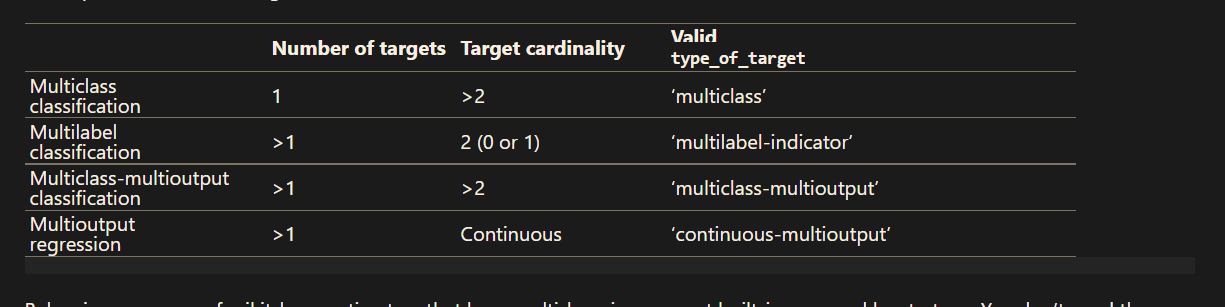

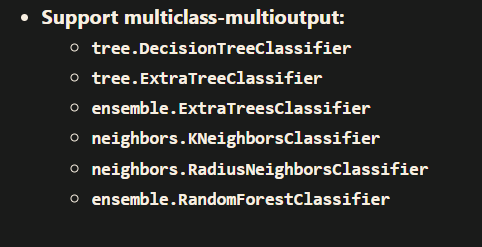

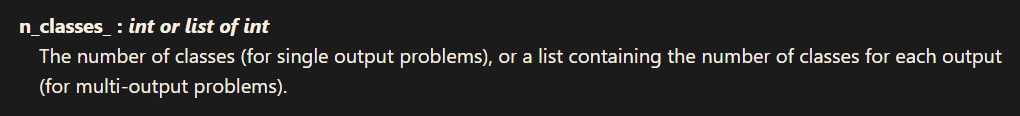

Creo una One Hot Encoding della colonna label:
- 0 = "Benign"
- 1 = "Malicious"

E una Label Encoding per la colonna detailed-label:
- 0 = None 
- 1 = Attack	
- 2 = C&C	
- 3 = C&C-FileDownload	
- 4 = C&C-HeartBeat	
- 5 = C&C-HeartBeat-FileDownload	
- 6 = C&C-Mirai	
- 7 = C&C-Torii	
- 8 = DDoS	
- 9 = FileDownload	
- 10 = Okiru	
- 11 = PartOfAHorizontalPortScan

Protocolli:
- 0 = icmp
- 1 = tcp
- 2 = udp

Servizio:
- 0 = dhcp
- 1 = dns
- 2 = http
- 3 = irc
- 4 = ssh
- 5 = ssl
- 6 = Non riconosciuto

Connection state:
- 0 = OTH: No SYN seen, just midstream traffic (a “partial connection” that was not later closed).
- 1 = REJ: Connection attempt rejected.
- 2 = RSTO: Connection established, originator aborted (sent a RST).

- 3 = RSTOS0: Originator sent a SYN followed by a RST, we never saw a SYN-ACK from the responder.

- 4 = RSTR: Responder sent a RST.

- 5 = RSTRH: Responder sent a SYN ACK followed by a RST, we never saw a SYN from the (purported) originator.

- 6 = S0: Connection attempt seen, no reply.

- 7 = S1: Connection established, not terminated.

- 8 = S2: Connection established and close attempt by originator seen (but no reply from responder).

- 9 = S3: Connection established and close attempt by responder seen (but no reply from originator).

- 10 = SF: Normal establishment and termination. Note that this is the same symbol as for state S1. You can tell the two apart because for S1 there will not be any byte counts in the summary, while for SF there will be.

- 11 = SH: Originator sent a SYN followed by a FIN, we never saw a SYN ACK from the responder (hence the connection was “half” open).

- 12 = SHR: Responder sent a SYN ACK followed by a FIN, we never saw a SYN from the originator.

In [ ]:
df.isnull().sum()

id.orig_p               0
id.resp_p               0
proto                   0
service           1434765
duration                0
orig_bytes              0
resp_bytes              0
conn_state              0
missed_bytes            0
history              3786
orig_pkts               0
orig_ip_bytes           0
resp_pkts               0
resp_ip_bytes           0
label                   0
detailed-label          0
dtype: int64

In [6]:
df = df.drop(axis=1, columns=["tunnel_parents","id.orig_h","id.resp_h","local_orig","local_resp","id.orig_p"])
df['duration'] = df['duration'].fillna(pd.Timedelta(seconds=0))
df['orig_bytes'] = df['orig_bytes'].fillna(0)
df['resp_bytes'] = df['resp_bytes'].fillna(0)
df['resp_ip_bytes'] = df['resp_ip_bytes'].fillna(0)
df['orig_ip_bytes'] = df['orig_ip_bytes'].fillna(0) 
df['conn_state'] = df['conn_state'].fillna('-') 
df['history'] = df['history'].fillna('-')
# duration
df['duration'].replace(to_replace=['-'], value=0, inplace=True)
# orig_bytes
df['orig_bytes'].replace(to_replace=['-'], value=0, inplace=True)
# orig_bytes
df['resp_bytes'].replace(to_replace=['-'], value=0, inplace=True)

In [7]:
orig_pkts_df = df.loc[:,('orig_pkts')].to_frame()
orig_pkts_df.rename(columns={'orig_pkts':'_orig_pkts_'}, inplace=True)

orig_pkts_df['orig_pkts']='0_10'
orig_pkts_df.loc[orig_pkts_df._orig_pkts_ > 10, 'orig_pkts'] = '10_10000'
orig_pkts_df.loc[orig_pkts_df._orig_pkts_ > 10000, 'orig_pkts'] = '>10000'

df['orig_pkts'] = orig_pkts_df['orig_pkts']
del orig_pkts_df

In [ ]:
df

,id.orig_p,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label,detailed-label
0,59932,80,tcp,NaN,0 days 00:00:03.097754,0.0,0.0,S0,0,S,0_10,180,0,0,Malicious,C&C
1,59932,80,tcp,NaN,0 days 00:00:00,0.0,0.0,S0,0,S,0_10,60,0,0,Malicious,C&C
2,59932,80,tcp,NaN,0 days 00:00:00,0.0,0.0,S0,0,S,0_10,60,0,0,Malicious,C&C
3,35883,53,udp,dns,0 days 00:00:05.005148,78.0,0.0,S0,0,D,0_10,134,0,0,Benign,-
4,43531,53,udp,dns,0 days 00:00:05.005145,78.0,0.0,S0,0,D,0_10,134,0,0,Benign,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1446656,123,123,udp,NaN,0 days 00:00:00.002732,48.0,48.0,SF,0,Dd,0_10,76,1,76,Benign,-
1446657,123,123,udp,NaN,0 days 00:00:00.058227,48.0,48.0,SF,0,Dd,0_10,76,1,76,Benign,-
1446658,123,123,udp,NaN,0 days 00:00:00.002738,48.0,48.0,SF,0,Dd,0_10,76,1,76,Benign,-
1446659,123,123,udp,NaN,0 days 00:00:00.033229,48.0,48.0,SF,0,Dd,0_10,76,1,76,Benign,-


In [8]:
import numpy as np
# Converto la durata da TimeDelta64 a secondi
df['duration'] = df[:]['duration'] / np.timedelta64(1, 's')

In [9]:
id_resp_p_df = df.loc[:,('id.resp_p')].to_frame()
id_resp_p_df.rename(columns={'id.resp_p':'_id_resp_p_'}, inplace=True)
id_resp_p_df['id.resp_p']='gt_65535'
id_resp_p_df.loc[id_resp_p_df._id_resp_p_ < 65536, 'id.resp_p'] = 'registered_p'
id_resp_p_df.loc[id_resp_p_df._id_resp_p_ < 1024, 'id.resp_p'] = 'well_known_p'
    # ssh
id_resp_p_df.loc[id_resp_p_df._id_resp_p_ == 22, 'id.resp_p'] = 'ssh'

# telnet
id_resp_p_df.loc[id_resp_p_df._id_resp_p_ == 23, 'id.resp_p'] = 'telnet'

# Message Processing Module [recv]
id_resp_p_df.loc[id_resp_p_df._id_resp_p_ == 45, 'id.resp_p'] = 'mpm'

# Domain Name Server
id_resp_p_df.loc[id_resp_p_df._id_resp_p_ == 53, 'id.resp_p'] = 'dns'

# World Wide Web HTTP 
id_resp_p_df.loc[id_resp_p_df._id_resp_p_ == 80, 'id.resp_p'] = 'http_80'

# ntp
id_resp_p_df.loc[id_resp_p_df._id_resp_p_ == 123, 'id.resp_p'] = 'ntp'

  # https
id_resp_p_df.loc[id_resp_p_df._id_resp_p_ == 443, 'id.resp_p'] = 'https'

  # mdqs
id_resp_p_df.loc[id_resp_p_df._id_resp_p_ == 666, 'id.resp_p'] = 'mdqs'

# World Wide Web HTTP 
id_resp_p_df.loc[id_resp_p_df._id_resp_p_ == 8080, 'id.resp_p'] = 'http_8080'

# World Wide Web HTTP 
id_resp_p_df.loc[id_resp_p_df._id_resp_p_ == 8081, 'id.resp_p'] = 'http_8081'

In [53]:
#df['id.resp_p'] = id_resp_p_df['id.resp_p']

In [10]:
# history
#   a SYN w/o the ACK bit set

history_df = df.loc[:,('history')].to_frame()

history_df['history_Ss'] = history_df['history'].replace(regex='[Ss]', value=1)
history_df['history_Ss'].replace(regex='[^1]', value=0, inplace=True)

#   a SYN+ACK (“handshake”)
history_df['history_Hh'] = history_df['history'].replace(regex='[Hh]', value=1)
history_df['history_Hh'].replace(regex='[^1]', value=0, inplace=True)

#   a pure ACK
history_df['history_Aa'] = history_df['history'].replace(regex='[Aa]', value=1)
history_df['history_Aa'].replace(regex='[^1]', value=0, inplace=True)

#   packet with payload (“data”)
history_df['history_Dd'] = history_df['history'].replace(regex='[Dd]', value=1)
history_df['history_Dd'].replace(regex='[^1]', value=0, inplace=True)

#   packet with FIN bit set
history_df['history_Ff'] = history_df['history'].replace(regex='[Ff]', value=1)
history_df['history_Ff'].replace(regex='[^1]', value=0, inplace=True)

#   packet with RST bit set
history_df['history_Rr'] = history_df['history'].replace(regex='[Rr]', value=1)
history_df['history_Rr'].replace(regex='[^1]', value=0, inplace=True)

#   packet with a bad checksum (applies to UDP too)
history_df['history_Cc'] = history_df['history'].replace(regex='[Cc]', value=1)
history_df['history_Cc'].replace(regex='[^1]', value=0, inplace=True)

#   a content gap
history_df['history_Gg'] = history_df['history'].replace(regex='[Gg]', value=1)
history_df['history_Gg'].replace(regex='[^1]', value=0, inplace=True)

#   packet with retransmitted payload
history_df['history_Tt'] = history_df['history'].replace(regex='[Tt]', value=1)
history_df['history_Tt'].replace(regex='[^1]', value=0, inplace=True)

#   packet with a zero window advertisement
history_df['history_Ww'] = history_df['history'].replace(regex='[Ww]', value=1)
history_df['history_Ww'].replace(regex='[^1]', value=0, inplace=True)

#   inconsistent packet (e.g. FIN+RST bits set)
history_df['history_Ii'] = history_df['history'].replace(regex='[Ii]', value=1)
history_df['history_Ii'].replace(regex='[^1]', value=0, inplace=True)

#   multi-flag packet (SYN+FIN or SYN+RST bits set)
history_df['history_Qq'] = history_df['history'].replace(regex='[Qq]', value=1)
history_df['history_Qq'].replace(regex='[^1]', value=0, inplace=True)

#   connection direction was flipped by Zeek’s heuristic
history_df['history_conn_flip'] = history_df['history'].replace(regex='[.^]', value=1)
history_df['history_conn_flip'].replace(regex='[^1]', value=0, inplace=True)

#   - dash -
history_df['history_unknown'] = history_df['history'].replace(to_replace=['-'], value=1)
history_df['history_unknown'].replace(regex='[^1]', value=0, inplace=True)

history_df.drop(['history'], axis=1, inplace=True)

In [11]:
df = df.join(history_df)
df = df.drop(axis=1, columns=["history"])
label = df.pop("label")
attack = df.pop("detailed-label")
df = df.join(label)
df = df.join(attack)
df

,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,missed_bytes,orig_pkts,orig_ip_bytes,...,history_Cc,history_Gg,history_Tt,history_Ww,history_Ii,history_Qq,history_conn_flip,history_unknown,label,detailed-label
0,80,tcp,NaN,3.097754,0.0,0.0,S0,0,0_10,180,...,0,0,0,0,0,0,0,0,Malicious,C&C
1,80,tcp,NaN,0.000000,0.0,0.0,S0,0,0_10,60,...,0,0,0,0,0,0,0,0,Malicious,C&C
2,80,tcp,NaN,0.000000,0.0,0.0,S0,0,0_10,60,...,0,0,0,0,0,0,0,0,Malicious,C&C
3,53,udp,dns,5.005148,78.0,0.0,S0,0,0_10,134,...,0,0,0,0,0,0,0,0,Benign,-
4,53,udp,dns,5.005145,78.0,0.0,S0,0,0_10,134,...,0,0,0,0,0,0,0,0,Benign,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1446656,123,udp,NaN,0.002732,48.0,48.0,SF,0,0_10,76,...,0,0,0,0,0,0,0,0,Benign,-
1446657,123,udp,NaN,0.058227,48.0,48.0,SF,0,0_10,76,...,0,0,0,0,0,0,0,0,Benign,-
1446658,123,udp,NaN,0.002738,48.0,48.0,SF,0,0_10,76,...,0,0,0,0,0,0,0,0,Benign,-
1446659,123,udp,NaN,0.033229,48.0,48.0,SF,0,0_10,76,...,0,0,0,0,0,0,0,0,Benign,-


In [12]:
# Creiamo una One Hot Encoding per la colonna Label
df['label'] = df['label'].str.title()
dummy1 = pd.get_dummies(df['label'], drop_first=True)
df['label'] = dummy1

# Creiamo una One Hot Encoding per la colonna detailed-label e proto
from sklearn.preprocessing import LabelEncoder
df['detailed-label'] = LabelEncoder().fit_transform(df['detailed-label'])
df['proto'] = LabelEncoder().fit_transform(df['proto'])
df['service'] = LabelEncoder().fit_transform(df['service'])
df['conn_state'] = LabelEncoder().fit_transform(df['conn_state'])
df['orig_pkts'] = LabelEncoder().fit_transform(df['orig_pkts'])
df['id.resp_p'] = LabelEncoder().fit_transform(df['id.resp_p'])
#df['id.orig_p'] = LabelEncoder().fit_transform(df['id.orig_p'])

In [91]:
df['service'].value_counts(dropna=False)
df['duration'].value_counts(dropna=False)
df['resp_bytes'].value_counts(dropna=False)
df['label'].value_counts(dropna=False)
df['detailed-label'].value_counts(dropna=False)
df['resp_ip_bytes'].value_counts(dropna=False)

KeyError: ignored

In [13]:
y = df[df.columns[-2:]]
X = df[df.columns[:-2]]

In [ ]:
#def rescale(data, new_min=0, new_max=1):
#    """Rescale the data to be within the range [new_min, new_max]"""
#    return (data - data.min()) / (data.max() - data.min()) * (new_max - new_min) + new_min

In [ ]:
#X_scaled = rescale(X)

In [ ]:
#X_scaled

In [ ]:
for column in df:
    print(df[column].value_counts())

In [14]:
# PREPROCESSING
from sklearn import preprocessing

scaler = preprocessing.Normalizer()
scaler.fit(X)
X_scaled = scaler.transform(X)
df[df.columns[:-2]] = X_scaled

In [ ]:
df

,id.orig_p,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,missed_bytes,orig_pkts,...,history_Cc,history_Gg,history_Tt,history_Ww,history_Ii,history_Qq,history_conn_flip,history_unknown,label,detailed-label
0,0.999995,0.001335,0.000017,0.000100,0.000052,0.000000,0.000000,0.000100,0.000000,0.000050,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1,2
1,0.999999,0.001335,0.000017,0.000100,0.000000,0.000000,0.000000,0.000100,0.000000,0.000017,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1,2
2,0.999999,0.001335,0.000017,0.000100,0.000000,0.000000,0.000000,0.000100,0.000000,0.000017,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1,2
3,0.999990,0.001477,0.000056,0.000028,0.000139,0.002174,0.000000,0.000167,0.000000,0.000056,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,0.999993,0.001218,0.000046,0.000023,0.000115,0.001792,0.000000,0.000138,0.000000,0.000046,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1446657,0.570025,0.570025,0.009269,0.027806,0.000270,0.222449,0.222449,0.046344,0.000000,0.004634,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1446658,0.570025,0.570025,0.009269,0.027806,0.000013,0.222449,0.222449,0.046344,0.000000,0.004634,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1446659,0.570025,0.570025,0.009269,0.027806,0.000154,0.222449,0.222449,0.046344,0.000000,0.004634,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1446660,0.070179,0.000816,0.000002,0.000011,0.081651,0.035793,0.035793,0.000013,0.008289,0.016343,...,0.000002,0.000002,0.0,0.0,0.0,0.0,0.0,0.0,1,7


In [ ]:
!pip install -U imbalanced-learn

     |████████████████████████████████| 199 kB 4.1 MB/s 
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.8.1
    Uninstalling imbalanced-learn-0.8.1:
      Successfully uninstalled imbalanced-learn-0.8.1


In [ ]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=0)


In [ ]:
X_res, y_res = ros.fit_resample(df[df.columns[:-1]], df[df.columns[-1:]])
ax = y_res.value_counts().plot.pie()
_ = ax.set_title("Over-sampling")

NameError: ignored

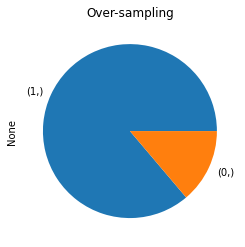

In [ ]:
ax = df[df.columns[-2:-1]].value_counts().plot.pie()
_ = ax.set_title("Over-sampling")

In [ ]:
X_res

In [ ]:
df

In [ ]:
X_res.shape

(9911172, 28)

In [ ]:
df.shape

(1446662, 29)

In [59]:
df = X_res
df = df.join(y_res)
X_scaled = df[df.columns[:-2]]
df

NameError: ignored

In [ ]:
df[df.columns[-2:-1]].value_counts()

MODELLI DI APPRENDIMENTO TRADIZIONALI:

In [14]:
X_scaled = X_scaled.astype(np.float32)

In [15]:
from sklearn.model_selection import train_test_split
y = df[df.columns[-2:-1]]
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.33)

In [62]:
y_train =  np.asarray(y_train["label"]).astype(np.float32)
y_test = np.asarray(y_test["label"]).astype(np.float32)

In [ ]:
#X_train = X_train.convert_dtypes()
#X_test = X_test.convert_dtypes()
#y_train = y_train.convert_dtypes()
#y_test = y_test.convert_dtypes()

In [ ]:
#X_train

In [63]:
from sklearn.ensemble import RandomForestClassifier
# creating a RF classifier
clf = RandomForestClassifier(n_estimators = 10, max_depth=7) 
 
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf.fit(X_train, y_train)
 
# performing predictions on the test dataset
y_pred = clf.predict(X_test)
# metrics are used to find accuracy or error
from sklearn import metrics 
print()
 
# using metrics module for accuracy calculation
print("ACCURACY OF THE MODEL: ", metrics.accuracy_score(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))


ACCURACY OF THE MODEL:  0.9611857985785168
              precision    recall  f1-score   support

         0.0       0.90      0.81      0.85     65940
         1.0       0.97      0.99      0.98    411308

    accuracy                           0.96    477248
   macro avg       0.94      0.90      0.91    477248
weighted avg       0.96      0.96      0.96    477248



RF sulla label multiclasse:

In [15]:
from sklearn.model_selection import train_test_split
y = df[df.columns[-1:]]
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, stratify=y['detailed-label'], test_size=0.33)

In [16]:
y_train =  np.asarray(y_train["detailed-label"]).astype(np.float32)
y_test = np.asarray(y_test["detailed-label"]).astype(np.float32)

In [17]:
from sklearn.ensemble import RandomForestClassifier
# creating a RF classifier
clf = RandomForestClassifier(n_estimators = 10, max_depth=7) 
 
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf.fit(X_train, y_train)
 
# performing predictions on the test dataset
y_pred = clf.predict(X_test)
# metrics are used to find accuracy or error
from sklearn import metrics 
print()
 
# using metrics module for accuracy calculation
print("ACCURACY OF THE MODEL: ", metrics.accuracy_score(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))


ACCURACY OF THE MODEL:  0.9551952024943007
              precision    recall  f1-score   support

         0.0       0.90      0.82      0.86     65931
         1.0       0.99      0.97      0.98      1292
         2.0       1.00      0.25      0.39      4985
         3.0       1.00      1.00      1.00     45796
         4.0       1.00      1.00      1.00     86687
         5.0       0.95      0.98      0.96    272557

    accuracy                           0.96    477248
   macro avg       0.97      0.84      0.87    477248
weighted avg       0.96      0.96      0.95    477248



RETE NEURALE:

In [18]:
X_scaled = np.asarray(X_scaled).astype(np.float32)

In [ ]:
X_scaled

array([[9.9999458e-01, 1.3348389e-03, 1.6685486e-05, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [9.9999857e-01, 1.3348443e-03, 1.6685553e-05, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [9.9999857e-01, 1.3348443e-03, 1.6685553e-05, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [5.7003123e-01, 5.7003123e-01, 9.2687998e-03, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [5.7003117e-01, 5.7003117e-01, 9.2687998e-03, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [5.7003117e-01, 5.7003117e-01, 9.2687998e-03, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], dtype=float32)

In [19]:
y = df[df.columns[-2:]]

12

In [20]:
import tensorflow as tf
import numpy as np

In [31]:
n_features = df.shape[1] - 2
n_clusters = len(df['detailed-label'].unique()) #nr di tipi di attacchi
# one-head multioutput model
input = tf.keras.layers.Input(shape=(n_features,), name='input')
hidden = tf.keras.layers.Dense(200, activation='relu', name='dense')(input)
hidden2 = tf.keras.layers.Dense(100, activation='relu', name='hidden2')(hidden)
hidden3 = tf.keras.layers.Dense(50, activation='relu', name='hidden3')(hidden2)
dropout = tf.keras.layers.Dropout(0.1, name='dropout')(hidden3)
intermediate_output = tf.keras.layers.Dense(n_clusters, activation='softmax', name='intermediate_output')(dropout)
#dropout2 = tf.keras.layers.Dropout(0.2, name='dropout2')(intermediate_output)
final_output = tf.keras.layers.Dense(2, activation='sigmoid', name='final_output')(intermediate_output)

In [32]:
one_head = tf.keras.Model(inputs=input, 
                          outputs=[intermediate_output, final_output], 
                          name='one-head-model')

In [33]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_intermediate_output_accuracy', patience=5)

In [34]:
one_head.compile(optimizer='adam',
                 loss=[tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                       tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)],
                 loss_weights=[0.5, 0.5],
                 metrics=['accuracy'])

In [ ]:
#X = np.asarray(X).astype(np.float32)

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, stratify=y['detailed-label'], test_size=0.33, random_state=42)

In [36]:
y_attack_train =  np.asarray(y_train["detailed-label"]).astype(np.float32)
y_label_train =  np.asarray(y_train["label"]).astype(np.float32)

y_attack_test =  np.asarray(y_test["detailed-label"]).astype(np.float32)
y_label_test = np.asarray(y_test["label"]).astype(np.float32)

In [ ]:
y_attack_train

array([5., 0., 5., ..., 5., 5., 4.], dtype=float32)

In [37]:
one_head.fit(X_train, [y_attack_train, y_label_train], epochs=50,
            validation_data=(X_test, [y_attack_test, y_label_test]),
            callbacks=[early_stopping])

Epoch 1/50
30280/30280 [==============================] - 146s 5ms/step - loss: 0.3253 - intermediate_output_loss: 0.4101 - final_output_loss: 0.2405 - intermediate_output_accuracy: 0.8554 - final_output_accuracy: 0.9086 - val_loss: 0.2733 - val_intermediate_output_loss: 0.3183 - val_final_output_loss: 0.2283 - val_intermediate_output_accuracy: 0.8864 - val_final_output_accuracy: 0.9107
Epoch 2/50
30280/30280 [==============================] - 143s 5ms/step - loss: 0.2473 - intermediate_output_loss: 0.3124 - final_output_loss: 0.1822 - intermediate_output_accuracy: 0.8902 - final_output_accuracy: 0.9309 - val_loss: 0.2060 - val_intermediate_output_loss: 0.2341 - val_final_output_loss: 0.1780 - val_intermediate_output_accuracy: 0.9110 - val_final_output_accuracy: 0.9344
Epoch 3/50
30280/30280 [==============================] - 132s 4ms/step - loss: 0.2098 - intermediate_output_loss: 0.2608 - final_output_loss: 0.1588 - intermediate_output_accuracy: 0.9063 - final_output_accuracy: 0.9403

In [38]:
# Prendo le predizioni [label | detailed-label] e considero label
y_pred = one_head.predict(X_test)
y_pred_label = np.argmax(y_pred[1][:], axis=1)

In [39]:
# Visualizzo le performance di predizione sulla label (benigno/maligno)
from sklearn.metrics import classification_report
print(classification_report(y_test['label'], y_pred_label))

              precision    recall  f1-score   support

           0       0.86      0.81      0.84     65931
           1       0.97      0.98      0.97    411317

    accuracy                           0.96    477248
   macro avg       0.91      0.90      0.91    477248
weighted avg       0.96      0.96      0.96    477248



In [40]:
# Visualizzo ora le performance di predizione sul tipo di attacco
y_pred_detailed = np.argmax(y_pred[0][:], axis=1)
print(classification_report(y_test['detailed-label'], y_pred_detailed))

              precision    recall  f1-score   support

           0       0.86      0.81      0.84     65931
           1       0.97      1.00      0.98      1292
           2       0.99      0.83      0.90      4985
           3       1.00      1.00      1.00     45796
           4       1.00      1.00      1.00     86687
           5       0.95      0.97      0.96    272557

    accuracy                           0.95    477248
   macro avg       0.96      0.93      0.95    477248
weighted avg       0.95      0.95      0.95    477248



In [ ]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
######################################################################################################################################################################################################################################